# Text Generation with Recurrent Neural Networks (RNNs)

In this assignment, you'll build upon your understanding of RNNs and Keras to develop a word-level text generation model.  Your goal is to train a model that learns the stylistic nuances of a chosen corpus and generates new, original text segments that echo the source material's essence.

**Datasets**

We've provided several intriguing text corpora to get you started:

*   Mark Twain
*   Charles Dickens
*   William Shakespeare

**Feel free to explore!**  If you have a particular passion for another author, genre, or a specific text, you're encouraged to use your own dataset of raw text.

In [18]:
# Check if we have a GPU available
import tensorflow as tf
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("No GPU available. If you're on Colab, go to Runtime > Change runtime and select a GPU hardware accelerator.")

Default GPU Device: /device:GPU:0


In [19]:
def download_file(url, file_path):
    import requests
    r = requests.get(url)
    with open(file_path, 'wb') as f:
        f.write(r.content)

def load_dataset(file_path, fraction=1.0):
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_text = f.read()
    return raw_text[:int(fraction * len(raw_text))]

dataset = 'shakespeare.txt' # Other options are mark_twain.txt, charles_dickens.txt

download_file(f'https://github.com/UofT-DSI/deep_learning/raw/main/assignments/downloaded_books/' + dataset, dataset)

# Load chosen dataset. NOTE: If Colab is running out of memory, change the `fraction` parameter to a value between 0 and 1 to load less data.
text = load_dataset(dataset, fraction=0.1)

# 1. Data Preparation (Complete or Incomplete)

Before we can begin training an RNN model, we need to prepare the dataset. This involves cleaning the text, tokenizing words, and creating sequences the model can be trained on.

## 1.1 Data Exploration

Print the first 1000 characters of the dataset. Report the dataset's size and the number of unique characters it contains.

In [20]:
# Your code here

print(text[:1000])


#report dataset size
dataset_size = len(text)
print(f"\nDataset size (number of characters): {dataset_size}")

#count unique characters
unique_chars = sorted(set(text))
num_unique_chars = len(unique_chars)
print(f"\nNumber of unique characters: {num_unique_chars}")
print(f"Unique characters: {unique_chars}")










<!DOCTYPE html>
<html
  lang="en"
  
  data-color-mode="auto" data-light-theme="light" data-dark-theme="dark"
  data-a11y-animated-images="system" data-a11y-link-underlines="true"
  
  >



  <head>
    <meta charset="utf-8">
  <link rel="dns-prefetch" href="https://github.githubassets.com">
  <link rel="dns-prefetch" href="https://avatars.githubusercontent.com">
  <link rel="dns-prefetch" href="https://github-cloud.s3.amazonaws.com">
  <link rel="dns-prefetch" href="https://user-images.githubusercontent.com/">
  <link rel="preconnect" href="https://github.githubassets.com" crossorigin>
  <link rel="preconnect" href="https://avatars.githubusercontent.com">

      <link rel="preload" href="https://github.githubassets.com/assets/global-banner-disable-f988792be49f.js" as="script" crossorigin>

  <link rel="preload" href="https://github.githubassets.com/assets/mona-sans-d1bf285e9b9b.woff2" as="font" type="font/woff2" crossorigin>


  <link crossorigin="anonymous" media="all" rel="s

## 1.2 Text Pre-Processing

To prepare the dataset for training, we need to clean the text and create a numerical representation the model can interpret. Perform the following pre-processing steps:

*   Convert the entire text to lowercase.
*   Use the `Tokenizer` class from the `keras.preprocessing.text` module to tokenize the text. You should fit the tokenizer on the text and then convert the text to a sequence of numbers. You can use the `texts_to_sequences` method to do this.

**Note**:
* You'll need to specify an appropriate size for the vocabulary. The number of words in the list of most common words can serve as a guide - does it seem like a reasonable vocabulary size?
* Some of the words will be excluded from the vocabulary, as they don't appear often enough. It's important to provide a value for `oov_token` when creating the Tokenizer instance, so that these words can be represented as "unknown".

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer


text = text.lower()
# Your code here
VOCAB_SIZE = 854
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token = OOV_TOKEN)
tokenizer.fit_on_texts([text])


#convert text to sequences of numbers
sequences = tokenizer.texts_to_sequences([text])[0]


print(f"Total words in the tokenizer: {len(tokenizer.word_index)}")
print(f"First 10 sequences: {sequences[:10]}")
print(f"Sample word-to-index mapping: {list(tokenizer.word_index.items())[:10]}")

Total words in the tokenizer: 853
First 10 sequences: [380, 115, 115, 381, 240, 16, 39, 241, 93, 16]
Sample word-to-index mapping: [('<OOV>', 1), ('github', 2), ('com', 3), ('script', 4), ('https', 5), ('1', 6), ('defer', 7), ('js', 8), ('assets', 9), ('githubassets', 10)]


If everything worked, the following line should show you the first 10 words in the vocabulary:

In [22]:
try:
    print(list(tokenizer.word_index.items())[:10])
except AttributeError:
    print("Tokenizer has not been initialized. Possible issue: Complete the relevant section of the assignment to initialize it."
)


[('<OOV>', 1), ('github', 2), ('com', 3), ('script', 4), ('https', 5), ('1', 6), ('defer', 7), ('js', 8), ('assets', 9), ('githubassets', 10)]


## 1.3 Sequence Generation

Now that the text has been tokenized, we need to create sequences the model can be trained on. There are two parts to this:

*   Use the `texts_to_sequences` method from the tokenizer to convert the text to a list of sequences of numbers.
*   Generate the training sequences. Each training sequence should contain `SEQ_LENGTH` token IDs from the text. The target token for each sequence should be the word that follows the sequence in the text.

In [23]:
import numpy as np

# Step 1: Convert text to sequences of numbers
sequences = tokenizer.texts_to_sequences([text])[0]

# Step 2: Generate the training sequences
X = []
y = []
SEQ_LENGTH = 50  # Define sequence length

# Loop through the text to create sequences
for i in range(SEQ_LENGTH, len(sequences)):
    X.append(sequences[i-SEQ_LENGTH:i])  # Input sequence (of length SEQ_LENGTH)
    y.append(sequences[i])  # Target word (next token after the sequence)

# Convert lists to numpy arrays for training
X = np.array(X)
y = np.array(y)

# Print some information
print(f"Total training sequences: {len(X)}")
print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (output words): {y.shape}")
print(f"First input sequence: {X[0]}")
print(f"First output word: {y[0]}")

Total training sequences: 3828
Shape of X (input sequences): (3828, 50)
Shape of y (output words): (3828,)
First input sequence: [380 115 115 381 240  16  39 241  93  16  54  57  54  16  51  57  51  16
 182 382 242 243  16 182  20 383  43 244  14 384 385 245  20  29 135 136
  25   5   2  10   3  20  29 135 136  25   5 246 183   3]
First output word: 20


Assuming your sequences are stored in `X` and the corresponding targets in `y`, the following line should print the first training sequence and its target:

In [25]:
if len(X) > 0 and len(y) > 0:
    print(f'Sequence: {X[0]}\nTarget: {y[0]}')
    print(f'Translated back to words: {[tokenizer.index_word[i] for i in X[0]]} -> {tokenizer.index_word[y[0]]}')
else:
    print("Training sequences have not been generated. Possible issue: Complete the relevant section of the assignment to initialize it.")


Sequence: [380 115 115 381 240  16  39 241  93  16  54  57  54  16  51  57  51  16
 182 382 242 243  16 182  20 383  43 244  14 384 385 245  20  29 135 136
  25   5   2  10   3  20  29 135 136  25   5 246 183   3]
Target: 20
Translated back to words: ['doctype', 'html', 'html', 'lang', 'en', 'data', 'color', 'mode', 'auto', 'data', 'light', 'theme', 'light', 'data', 'dark', 'theme', 'dark', 'data', 'a11y', 'animated', 'images', 'system', 'data', 'a11y', 'link', 'underlines', 'true', 'head', 'meta', 'charset', 'utf', '8', 'link', 'rel', 'dns', 'prefetch', 'href', 'https', 'github', 'githubassets', 'com', 'link', 'rel', 'dns', 'prefetch', 'href', 'https', 'avatars', 'githubusercontent', 'com'] -> link


And the following code will transform y into a one-hot encoded matrix, and split everything into training and validation sets:

In [26]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import numpy as np

# Ensure that tokenizer has been initialized
if tokenizer is not None:
    # Convert X and y to numpy arrays
    X = np.array(X)
    y = np.array(y)


    if OOV_TOKEN in tokenizer.word_index:
        mask = y != tokenizer.word_index[OOV_TOKEN]
        X = X[mask]
        y = y[mask]

    #one-hot encode the target token
    y = to_categorical(y, num_classes=VOCAB_SIZE)

    #split the data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f'X_train shape: {X_train.shape}')
    print(f'y_train shape: {y_train.shape}')
else:
    print("Tokenizer has not been initialized. Please initialize it and load the vocabulary before continuing.")


X_train shape: (3062, 50)
y_train shape: (3062, 854)


# 2. Model Development (Complete or Incomplete)

With the dataset prepared, it's time to develop the RNN model. You'll need to define the architecture of the model, compile it, and prepare it for training.

## 2.1 Model Architecture

Define the architecture of your RNN model. You can design it however you like, but there are a few features that it's important to include:

*   An embedding layer that learns a dense representation of the input tokens. You'll need to specify the input dimension (the size of the vocabulary) and the output dimension (the size of the dense representation). Remember, you can look at the documentation [here](https://keras.io/api/layers/core_layers/embedding/).
*   At least one recurrent layer. We have learned how to use LSTM layers in class, but you can use other types of recurrent layers if you prefer. You can find the documentation [here](https://keras.io/api/layers/recurrent_layers/lstm/).
*   A dense layer with a softmax activation function. This layer will output a probability distribution over the vocabulary, so that the model can make predictions about the next token.

In [27]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [28]:
vocab_size = len(tokenizer.word_index) + 1

In [29]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])


model(np.zeros((1, SEQ_LENGTH), dtype=np.int32))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (1, 50, 100)                │          85,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (1, 128)                    │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 854)                    │         110,166 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 312,814 (1.19 MB)

 Trainable params: 312,814 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

## 2.2 Model Compilation

Compile the model with an appropriate loss function and optimizer. You might also want to track additional metrics, such as accuracy.

Give a short explanation of your choice of loss function and optimizer:

_your explanation here_

In [30]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In this multi-class next-word prediction setting, categorical crossentropy is ideal for measuring the difference between the true label (the one‐hot vector) and the predicted probability distribution over the entire vocabulary. As for the optimizer, Adam combines the strengths of AdaGrad and RMSProp to adapt the learning rate for each parameter individually, typically resulting in faster convergence and stable performance across a wide range of neural network tasks.

## 2.3 Model Training

Train the model on the training data you've prepared.

* Train your model for 5 epochs with a batch size of 128. Use the validation data for validation.
* Store the training history in a variable called `history`.

In [31]:
# Your code here
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    verbose=1
)


Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0443 - loss: 6.6497 - val_accuracy: 0.0483 - val_loss: 5.7858
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0294 - loss: 5.6570 - val_accuracy: 0.0196 - val_loss: 5.8630
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0341 - loss: 5.5683 - val_accuracy: 0.0483 - val_loss: 5.8468
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0339 - loss: 5.5121 - val_accuracy: 0.0587 - val_loss: 5.7177
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0526 - loss: 5.3707 - val_accuracy: 0.0822 - val_loss: 5.6085


Plot the training history to visualize the model's learning progress. Your plot should include the training and validation loss.

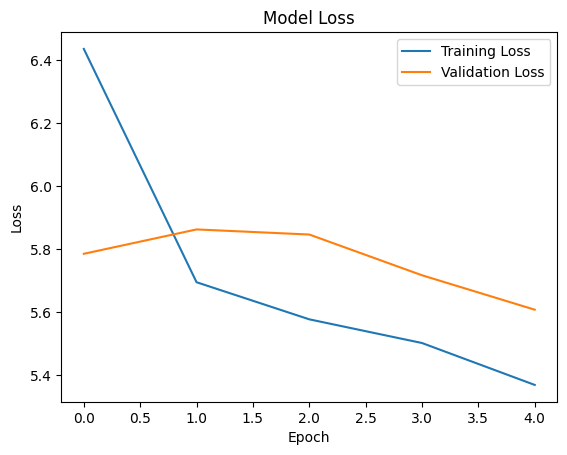

In [32]:
import matplotlib.pyplot as plt

# Your code here
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 3. Text Generation (Complete or Incomplete)

Write a method called `generate_text` that uses the trained model to generate new text. The method should take the following parameters:

*   `model`: The trained RNN model.
*   `tokenizer`: The tokenizer used to pre-process the text data.
*   `seed_text`: The seed text the model will use to generate new text.
*   `max_sequence_len`: The maximum length of the sequence used to generate new text.

The method should return the generated text.

An overview of the text generation process you should follow:

1. Tokenize the seed text using the tokenizer we built before.
2. Pad the sequences to the same length as the training sequences - you can use the `pad_sequences` method from the `keras.preprocessing.sequence` module, which is documented [here](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences).
3. Use the model to predict the next token in the sequence. Remember that the model will output a probability distribution over the vocabulary, so you'll need to use `np.argmax` to find the token with the highest probability.
4. Add the predicted token to the sequence and remove the first token.
5. Repeat steps 3-4 until you have generated the desired number of tokens.
6. Convert the generated token IDs back to words and return the combined result as a single string.

This is a challenging task, so don't hesitate to ask for help if you need it. It's okay if the generated text doesn't make much sense yet - we'll work on improving the model next.
As a bonus, you can make your method generate "gpt-style" by having it print out each word as it's generated, so you can see the text being generated in real time.

In [34]:
from keras.preprocessing.sequence import pad_sequences

def get_predicted_word(model, sequence):
    """
    Get the predicted word from the model.
    This helper function uses a concept we haven't covered in class yet: temperature.
    In essence, a little bit of randomness in what word we predict can make the text more interesting.
    """


    # Use the model to predict the next token in the sequence
    yhat = model.predict(sequence, verbose=0)

    # Get the index of the predicted word, according to the probabilities
    yhat = np.random.choice(range(VOCAB_SIZE), p=yhat.ravel())

    return yhat

def generate_text(model, tokenizer, seed_text, max_sequence_len):
    """
    Generate new text using the trained model.
    You can use the `get_predicted_word` helper function to help you with this.
    """

    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    generated_text = seed_text
    num_tokens_to_generate = 30
    for _ in range(num_tokens_to_generate):

        padded_sequence = pad_sequences([token_list],
                                        maxlen=max_sequence_len,
                                        padding='pre',
                                        truncating='pre')

        #predict the next token ID using our helper function
        predicted_token_id = get_predicted_word(model, padded_sequence)

        #convert that token ID back into a word from the tokenizer’s word_index
        predicted_word = None
        for word, idx in tokenizer.word_index.items():
            if idx == predicted_token_id:
                predicted_word = word
                break

        #if we didn't find a matching word, treat it as OOV
        if predicted_word is None:
            predicted_word = "<OOV>"

        #append this word to the generated text
        generated_text += " " + predicted_word

        #update token_list: add the predicted ID, then remove the oldest token
        token_list.append(predicted_token_id)
        token_list = token_list[1:]

    return generated_text




In [35]:
# Test the text generation function
generate_text(model, tokenizer, 'hamlet', SEQ_LENGTH)

'hamlet item 730dca81d0a2 src com quot packages class 225433424a87 s3 2 be8cb88f481b application d class 0 class crossorigin script details githubassets 1 data on of assets meta in only js data'

It's likely that the text generated by your model doesn't make much sense yet. This is because the model hasn't been trained for very long, and the training dataset is relatively small.

# 4. Model Refinement (Complete or Incomplete)

In this last section, you'll work on improving your model. There are many ways to do this, but here are a few ideas to get you started:

* Use pre-trained embeddings: the code below will help you to load pre-trained embeddings through Keras.
* Experiment with different model architectures, including the number of layers, the number of units in each layer, and the use of dropout layers.
* Train your model for longer. You can also experiment with different batch sizes.

Implement and test out at least one of these ideas. If you have other ideas for improving the model, feel free to try them out as well.

In [36]:
!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip glove.6B.zip

--2025-03-13 16:36:07--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  4.85MB/s    in 2m 44s  

2025-03-13 16:38:51 (5.02 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [37]:
# Load the pre-trained embeddings
embeddings_index = {}
try:
    with open('glove.6B.100d.txt', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f'Found {len(embeddings_index)} word vectors.')
except FileNotFoundError:
    print("'glove.6B.100d.txt' File not found. Please make sure you have ran the previous cell.")

Found 400000 word vectors.


In [38]:
# Check if VOCAB_SIZE is set
if VOCAB_SIZE is None:
    print("You need to complete the previous parts of your assignment in order for this to work.")
else:
    # Create an embedding matrix
    embedding_matrix = np.zeros((VOCAB_SIZE, 100))
    for word, i in tokenizer.word_index.items():
        if i < VOCAB_SIZE:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

In [39]:
# Check if VOCAB_SIZE is set
if VOCAB_SIZE is None:
    print("You need to complete the previous parts of your assignment in order for this to work.")
else:
    embedding_layer = Embedding(
        VOCAB_SIZE, 100, weights=[embedding_matrix], input_length=SEQ_LENGTH, trainable=False
    )

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [42]:
embedding_dim = 100  # or 50, 200, 300 depending on your pre-trained embeddings


Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.0355 - loss: 6.1936 - val_accuracy: 0.0326 - val_loss: 5.6260
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0604 - loss: 5.3084 - val_accuracy: 0.1266 - val_loss: 5.2500
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1291 - loss: 4.7634 - val_accuracy: 0.2063 - val_loss: 4.8061
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1824 - loss: 4.2749 - val_accuracy: 0.2650 - val_loss: 4.5299
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2410 - loss: 3.9032 - val_accuracy: 0.2859 - val_loss: 4.4189
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2769 - loss: 3.6940 - val_accuracy: 0.3107 - val_loss: 4.2438
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2963 - loss: 3.5160 - val_accuracy: 0.3551 - val_loss: 4.1418
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3609 - loss: 3.2024 - val_accuracy: 0.3564 - v

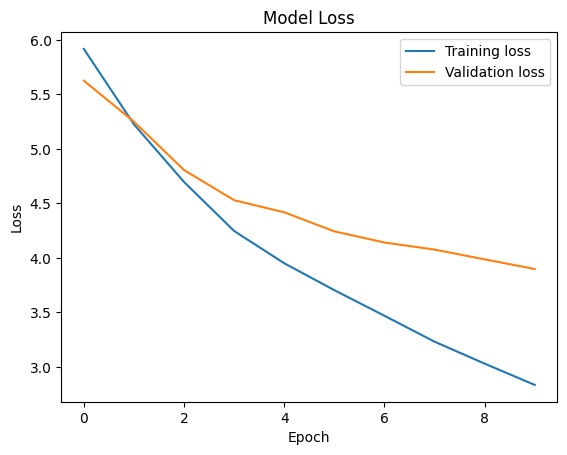

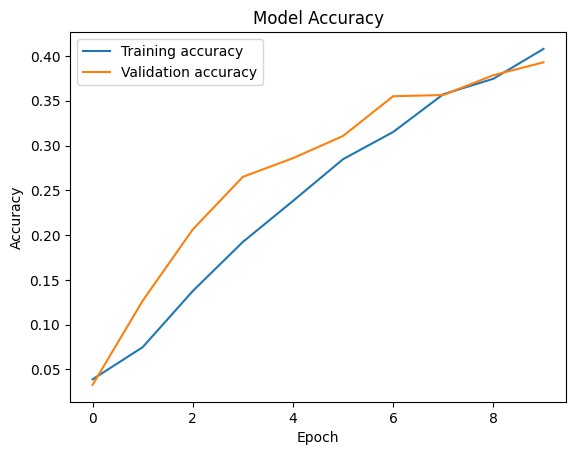

In [43]:
# Define a new model and train it
model = Sequential()

# Use pre-trained embeddings (if not using GloVe, you can omit the weights parameter)
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=SEQ_LENGTH,
    weights=[embedding_matrix],  # comment out if not using pre-trained embeddings
    trainable=False             # set True if you want to fine-tune GloVe
))

# Add one or more LSTM layers
model.add(LSTM(256, return_sequences=True))  # bigger hidden size, optional
model.add(Dropout(0.2))                      # dropout to reduce overfitting
model.add(LSTM(256))
model.add(Dropout(0.2))

# Final classification layer
model.add(Dense(vocab_size, activation='softmax'))

# 2. Compile the model
opt = Adam(learning_rate=0.001)  # adjust learning rate if desired
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# 3. Train the model
# Assumes you have X_train, y_train, X_val, and y_val ready for training
history = model.fit(
    X_train, y_train,
    epochs=10,              # consider training longer if dataset is large
    batch_size=64,          # experiment with different batch sizes
    validation_data=(X_val, y_val)
)

# 4. (Optional) Inspect training history
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨**Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)**🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.